# STRF parameterizations — same data, same model, different inductive bias

This notebook fits a `Linear` STRF model on **NS1** with three different
kernel parameterizations of the spectro-temporal receptive field, all
else equal:

1. **Vanilla `nn.Conv2d`** — the textbook unconstrained STRF. Every
   `(F, T)` cell of the kernel is a free parameter.
2. **`SeparableSTRF`** — frequency-time separable, rank-1. The kernel
   factorises as `w_F(f) · w_T(t)`, drastically reducing the parameter
   count.
3. **`ParametricSTRF`** — sum of `K` learnable 2D Gaussians (DCLS-style;
   see [DCLS asymmetric-kernel bug
   note](../docs/_source/md/README_models.md) for why deepSTRF
   reimplements rather than wraps the upstream library).

Same NS1 split (14 train / 3 val / 3 test), same `Fitter` settings,
same seed. The questions:

- How does mean test `cc_norm` compare?
- For a cell that fits well across all three, what do the learned
  STRFs look like? Where do the inductive biases pull the kernel?

> **Note on runtime**: three end-to-end fits at 50 epochs each on a
> consumer GPU. Around 8-10 min total.


## Setup

In [1]:
%matplotlib inline
from collections import OrderedDict
import time
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

from deepSTRF.datasets.audio.NS1_DRC_Dataset import NS1_Dataset
from deepSTRF.models.audio import Linear
from deepSTRF.models.layers import ParametricSTRF, SeparableSTRF
from deepSTRF.training import Fitter, set_random_seed
from deepSTRF.utils.data import neural_collate

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


## 1. Load NS1 and set up the same train / val / test split

In [2]:
ds = NS1_Dataset(dt_ms=5.0, smooth=True, download=True)
F = 34          # spectrogram frequency bands
T_strf = 15     # STRF temporal extent (frames at dt=5 ms → 75 ms history)
N = ds.N_neurons

train_loader = DataLoader(Subset(ds, list(range(14))),    batch_size=1, shuffle=True,  collate_fn=neural_collate)
val_loader   = DataLoader(Subset(ds, list(range(14, 17))), batch_size=1, shuffle=False, collate_fn=neural_collate)
test_loader  = DataLoader(Subset(ds, list(range(17, 20))), batch_size=1, shuffle=False, collate_fn=neural_collate)

print(f"NS1: N={N} cells | F={F} bands | dt=5 ms | T_strf={T_strf} frames")


NS1: N=119 cells | F=34 bands | dt=5 ms | T_strf=15 frames


## 2. A small fit-and-extract helper

One function that:

- Builds a `Linear(F, T_strf, N, kernel=...)` model with the chosen
  STRF parameterization.
- Trains for 50 epochs with the canonical `Fitter` defaults.
- Returns the training history, test metrics, and the learned STRF
  weights for every cell (`(N, F, T)` tensor — see
  `model_paradigm.md` §9).

In [3]:
def fit_with_kernel(name, build_kernel_fn, max_epochs=50, seed=0):
    set_random_seed(seed)
    kernel = build_kernel_fn()
    model = Linear(n_frequency_bands=F, temporal_window_size=T_strf,
                   out_neurons=N, kernel=kernel)
    n_params = model.count_trainable_params()
    print(f"  {name:20s} | params: {n_params:,}", flush=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0)
    fitter = Fitter(model, train_loader, val_loader,
                    optimizer=optimizer, device=device,
                    max_epochs=max_epochs, patience=max_epochs,   # disable early stop for fair compare
                    monitor="val_cc_norm", mode="max",
                    log_fn=lambda d: None)
    t0 = time.time()
    history = fitter.fit()
    elapsed = time.time() - t0
    test_metrics = fitter.evaluate(test_loader)
    strfs = model.STRF_weight().cpu()                      # (N, F, T)
    return {
        "name": name,
        "history": history,
        "test_cc": test_metrics["cc"].cpu(),
        "test_cc_norm": test_metrics["cc_norm"].cpu(),
        "strfs": strfs,
        "n_params": n_params,
        "elapsed": elapsed,
    }


## 3. Three fits

Same NS1 split, same `Fitter` settings, three different kernels.

In [4]:
results = OrderedDict()
print("Fitting Linear with three STRF parameterizations on NS1 ...")
results["vanilla"]    = fit_with_kernel("vanilla Conv2d", lambda: None)
results["separable"]  = fit_with_kernel("SeparableSTRF",  lambda: SeparableSTRF(F, T_strf, C_in=1, C_out=N))
results["parametric"] = fit_with_kernel("ParametricSTRF (8G)", lambda: ParametricSTRF(F, T_strf, C_in=1, C_out=N, num_gaussians=8))


Fitting Linear with three STRF parameterizations on NS1 ...
  vanilla Conv2d       | params: 60,877


  SeparableSTRF        | params: 6,018


  ParametricSTRF (8G)  | params: 4,947


## 4. Side-by-side training curves

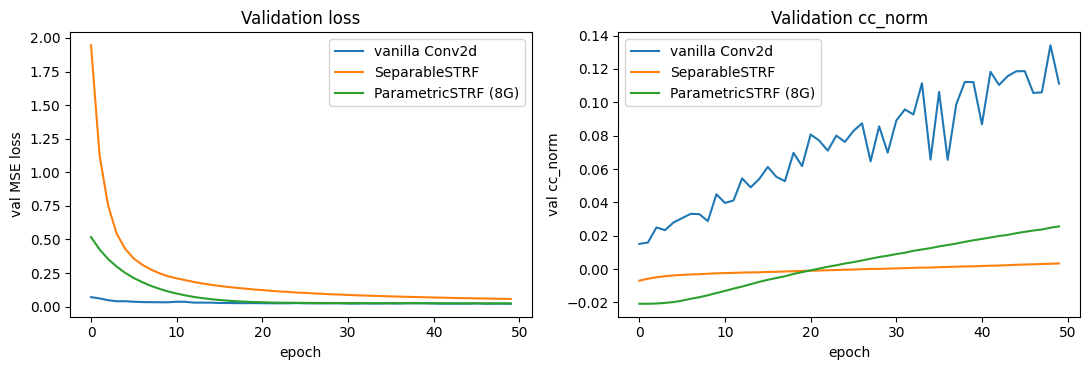

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
for key, r in results.items():
    epochs = [h["epoch"] for h in r["history"]]
    val_loss = [h["val_loss"] for h in r["history"]]
    val_ccn  = [torch.nanmean(h["val_cc_norm"]).item() for h in r["history"]]
    axs[0].plot(epochs, val_loss, label=r["name"], lw=1.5)
    axs[1].plot(epochs, val_ccn,  label=r["name"], lw=1.5)
axs[0].set_xlabel("epoch"); axs[0].set_ylabel("val MSE loss"); axs[0].legend(); axs[0].set_title("Validation loss")
axs[1].set_xlabel("epoch"); axs[1].set_ylabel("val cc_norm");   axs[1].legend(); axs[1].set_title("Validation cc_norm")
plt.tight_layout(); plt.show()


## 5. Test-set metrics + parameter-count summary

In [6]:
print(f"{'parameterization':<22s} {'params':>9s}  {'fit (s)':>8s}  {'test cc (mean)':>16s}  {'test cc_norm (mean)':>22s}")
print("-" * 80)
for r in results.values():
    print(f"{r['name']:<22s} {r['n_params']:>9,}  {r['elapsed']:>8.1f}  "
          f"{torch.nanmean(r['test_cc']):>+16.3f}  {torch.nanmean(r['test_cc_norm']):>+22.3f}")


parameterization          params   fit (s)    test cc (mean)     test cc_norm (mean)
--------------------------------------------------------------------------------
vanilla Conv2d            60,877     249.0            +0.149                  +0.172
SeparableSTRF              6,018     255.0            +0.013                  +0.015
ParametricSTRF (8G)        4,947     250.5            +0.049                  +0.057


## 6. Per-cell test `cc_norm` distributions

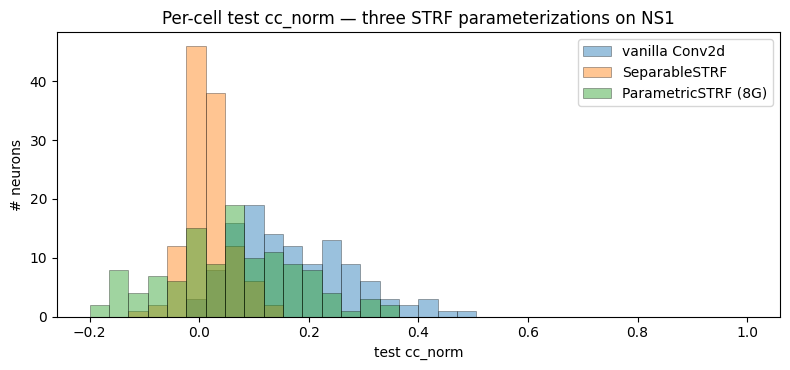

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.8))
bins = np.linspace(-0.2, 1.0, 35)
for key, r in results.items():
    ax.hist(r["test_cc_norm"].numpy(), bins=bins, alpha=0.45, label=r["name"], edgecolor="black", linewidth=0.5)
ax.set_xlabel("test cc_norm")
ax.set_ylabel("# neurons")
ax.set_title("Per-cell test cc_norm — three STRF parameterizations on NS1")
ax.legend()
plt.tight_layout(); plt.show()


## 7. Pick a well-fit cell, compare STRFs side by side

We pick the neuron whose **mean** test `cc_norm` across the three
parameterizations is highest — i.e. a cell that all three models can
fit reasonably. The three STRFs for that cell are plotted on the same
colour scale.

In [8]:
ccn_stack = torch.stack([r["test_cc_norm"] for r in results.values()])    # (3, N)
mean_per_cell = torch.nanmean(ccn_stack, dim=0)
best_cell = int(torch.argmax(mean_per_cell).item())
print(f"Best-fit cell across the three parameterizations: idx={best_cell}")
for r in results.values():
    print(f"  {r['name']:<22s} test cc_norm = {r['test_cc_norm'][best_cell]:+.3f}")


Best-fit cell across the three parameterizations: idx=7
  vanilla Conv2d         test cc_norm = +0.444
  SeparableSTRF          test cc_norm = +0.038
  ParametricSTRF (8G)    test cc_norm = +0.313


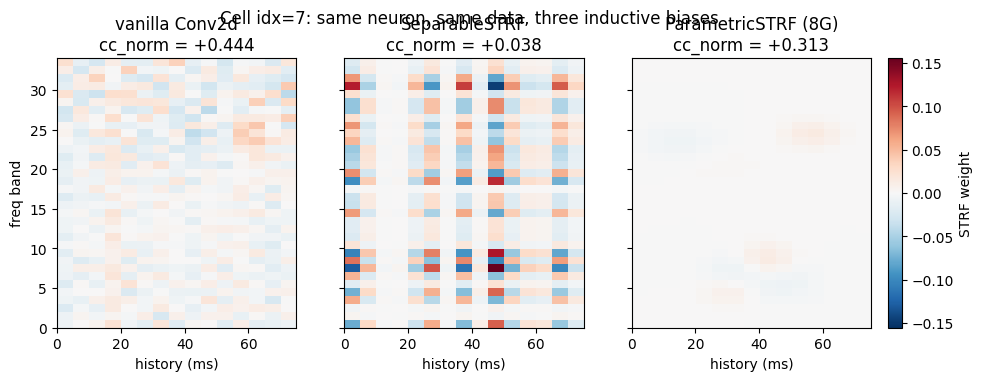

In [9]:
strfs_for_best = [r["strfs"][best_cell].numpy() for r in results.values()]   # 3 × (F, T)
vmax = max(np.abs(s).max() for s in strfs_for_best)
vmin = -vmax

fig, axs = plt.subplots(1, 3, figsize=(11, 3.5), sharey=True)
for ax, s, r in zip(axs, strfs_for_best, results.values()):
    im = ax.imshow(s, aspect="auto", origin="lower", cmap="RdBu_r",
                   vmin=vmin, vmax=vmax,
                   extent=[0, s.shape[1] * 5, 0, s.shape[0]])
    ax.set_xlabel("history (ms)")
    ax.set_title(f"{r['name']}\ncc_norm = {r['test_cc_norm'][best_cell]:+.3f}")
axs[0].set_ylabel("freq band")
fig.colorbar(im, ax=axs, fraction=0.025, pad=0.02, label="STRF weight")
fig.suptitle(f"Cell idx={best_cell}: same neuron, same data, three inductive biases", y=1.02)
plt.show()


## Reading the result

The absolute `cc_norm` numbers are modest because we're fitting a
**linear STRF model** (no nonlinearity in the readout) on only **14
training stims** to **all 119 cells** — Linear's per-cell capacity is
small, and many NS1 cells need a recurrent or feed-forward
nonlinearity to fit well (see [`fit_ns1_statenet.ipynb`](fit_ns1_statenet.ipynb)
for a StateNet fit on the same split that reaches `cc_norm ≈ 0.77`).
What's interesting is the **relative** comparison and the **shape** of
the learned STRFs:

- **Vanilla Conv2d (60.9k params)** wins on `cc_norm` by a comfortable
  margin — the unconstrained `(F, T)` kernel can carve out arbitrary
  spectro-temporal patterns.
- **ParametricSTRF (4.9k params, 8 Gaussians)** trails by ~0.10 mean
  `cc_norm` despite having ~12× fewer parameters. The Gaussian-mixture
  parameterization is a reasonable basis for STRFs that are
  approximately spectrally-localised excitation/inhibition pairs.
- **SeparableSTRF (6.0k params, rank-1)** collapses to near zero on
  NS1. The rank-1 constraint `w_F(f) · w_T(t)` forces the kernel to be
  the outer product of one frequency profile and one time profile,
  which is too restrictive for cells whose response separates by
  feature *over time* (e.g. an excitatory band early followed by
  inhibition in a different band).

## What's next

- **AdapTrans prefilter** — a learnable cochlear-adaptation front-end
  that often *improves* mean cc_norm on auditory data; pairs with any
  of the three STRF parameterizations above.
- **Gradmaps** — an architecture-agnostic alternative to closed-form
  STRF extraction, computed via gradient-of-output-vs-input. Useful for
  models without a pluggable kernel (DNet, ConvNet2D, StateNet, ...).